# 06 Result Summary

## 1. Load Output Files

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

OUTPUT_DIR = Path("outputs")
BASELINE_DIR = OUTPUT_DIR / "baseline"
AGG_DIR = OUTPUT_DIR / "aggregate_only"
ALL_DIR = OUTPUT_DIR / "all_features"
SUMMARY_DIR = OUTPUT_DIR / "final_summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

baseline_metrics = pd.read_csv(BASELINE_DIR / "baseline_metrics.csv")
agg_summary = pd.read_csv(AGG_DIR / "summary.csv", index_col=0)
all_summary = pd.read_csv(ALL_DIR / "summary.csv", index_col=0)

baseline_importance = pd.read_csv(BASELINE_DIR / "baseline_logistic_coefficients.csv")
agg_importance = pd.read_csv(AGG_DIR / "feature_importance.csv")
all_importance = pd.read_csv(ALL_DIR / "feature_importance.csv")
all_group_importance = pd.read_csv(ALL_DIR / "feature_group_importance.csv")

display(baseline_metrics)
display(agg_summary)
display(all_summary)

,Feature_Set,Model,Val_Accuracy,Val_AUC,Val_F1,Test_Accuracy,Test_AUC,Test_F1,Feature_Count
0,Raw encoded features / no feature engineering,LogisticRegression,0.698811,0.775603,0.695838,0.705252,0.782813,0.702758,185


,Val_AUC,Test_Accuracy,Test_AUC,Test_F1,AUC_Rank,Gap_vs_Best_AUC,Gap_vs_LogReg_AUC
CatBoost,0.773388,0.703647,0.782165,0.699727,1,0.000000,0.000923
XGBoost,0.773156,0.703282,0.781890,0.698577,2,0.000274,0.000648
LightGBM,0.772869,0.704158,0.781830,0.700089,3,0.000335,0.000587
LogisticRegression,0.772192,0.703647,0.781242,0.701228,4,0.000923,0.000000
RandomForest,0.771255,0.703282,0.780066,0.699734,5,0.002098,-0.001176
DecisionTree,0.763067,0.699562,0.774315,0.693823,6,0.007850,-0.006927


,Val_AUC,Test_Accuracy,Test_AUC,Test_F1,AUC_Rank,Gap_vs_Best_AUC,Gap_vs_LogReg_AUC
CatBoost,0.793348,0.713713,0.798923,0.710182,1,0.000000,0.001857
LightGBM,0.792074,0.715755,0.798038,0.712759,2,0.000885,0.000971
XGBoost,0.792851,0.714588,0.797692,0.711068,3,0.001231,0.000625
LogisticRegression,0.792672,0.717433,0.797066,0.715691,4,0.001857,0.000000
RandomForest,0.772104,0.702334,0.780712,0.698129,5,0.018211,-0.016354
DecisionTree,0.765934,0.699635,0.775463,0.691073,6,0.023460,-0.021603


## 2. Overall Model Summary

In [12]:
def best_row(summary_df):
    row = summary_df.sort_values("Test_AUC", ascending=False).iloc[0]
    return row.name, row


def logreg_row(summary_df):
    row = summary_df.loc["LogisticRegression"]
    return "LogisticRegression", row


agg_best_model, agg_best = best_row(agg_summary)
all_best_model, all_best = best_row(all_summary)
agg_logreg_model, agg_logreg = logreg_row(agg_summary)
all_logreg_model, all_logreg = logreg_row(all_summary)

baseline_row = baseline_metrics.iloc[0]
agg_feature_count = pd.read_csv(AGG_DIR / "final_metrics.csv").iloc[0].get("Feature_Count", np.nan) if (AGG_DIR / "final_metrics.csv").exists() else np.nan
all_feature_count = pd.read_csv(ALL_DIR / "final_metrics.csv").iloc[0].get("Feature_Count", np.nan) if (ALL_DIR / "final_metrics.csv").exists() else np.nan

overall_rows = [
    {
        "Notebook": "03_baseline_model_kaggle",
        "Feature_Set": "Baseline raw encoded features",
        "Selected_Model_Type": "LogisticRegression",
        "Model": baseline_row["Model"],
        "Val_AUC": baseline_row["Val_AUC"],
        "Test_Accuracy": baseline_row["Test_Accuracy"],
        "Test_AUC": baseline_row["Test_AUC"],
        "Test_F1": baseline_row["Test_F1"],
        "Feature_Count": baseline_row["Feature_Count"],
    },
    {
        "Notebook": "04_modeling_aggregate_only",
        "Feature_Set": "Aggregate-only engineered features",
        "Selected_Model_Type": "BestModel",
        "Model": agg_best_model,
        "Val_AUC": agg_best["Val_AUC"],
        "Test_Accuracy": agg_best["Test_Accuracy"],
        "Test_AUC": agg_best["Test_AUC"],
        "Test_F1": agg_best["Test_F1"],
        "Feature_Count": agg_feature_count,
    },
    {
        "Notebook": "04_modeling_aggregate_only",
        "Feature_Set": "Aggregate-only engineered features",
        "Selected_Model_Type": "LogisticRegression",
        "Model": agg_logreg_model,
        "Val_AUC": agg_logreg["Val_AUC"],
        "Test_Accuracy": agg_logreg["Test_Accuracy"],
        "Test_AUC": agg_logreg["Test_AUC"],
        "Test_F1": agg_logreg["Test_F1"],
        "Feature_Count": agg_feature_count,
    },
    {
        "Notebook": "05_modeling_all_features",
        "Feature_Set": "Combined aggregate + champion/setup features",
        "Selected_Model_Type": "BestModel",
        "Model": all_best_model,
        "Val_AUC": all_best["Val_AUC"],
        "Test_Accuracy": all_best["Test_Accuracy"],
        "Test_AUC": all_best["Test_AUC"],
        "Test_F1": all_best["Test_F1"],
        "Feature_Count": all_feature_count,
    },
    {
        "Notebook": "05_modeling_all_features",
        "Feature_Set": "Combined aggregate + champion/setup features",
        "Selected_Model_Type": "LogisticRegression",
        "Model": all_logreg_model,
        "Val_AUC": all_logreg["Val_AUC"],
        "Test_Accuracy": all_logreg["Test_Accuracy"],
        "Test_AUC": all_logreg["Test_AUC"],
        "Test_F1": all_logreg["Test_F1"],
        "Feature_Count": all_feature_count,
    },
]

overall_summary = pd.DataFrame(overall_rows)
overall_summary.to_csv(SUMMARY_DIR / "overall_model_summary.csv", index=False)
display(overall_summary)

,Notebook,Feature_Set,Selected_Model_Type,Model,Val_AUC,Test_Accuracy,Test_AUC,Test_F1,Feature_Count
0,03_baseline_model_kaggle,Baseline raw encoded features,LogisticRegression,LogisticRegression,0.775603,0.705252,0.782813,0.702758,185
1,04_modeling_aggregate_only,Aggregate-only engineered features,BestModel,CatBoost,0.773388,0.703647,0.782165,0.699727,50
2,04_modeling_aggregate_only,Aggregate-only engineered features,LogisticRegression,LogisticRegression,0.772192,0.703647,0.781242,0.701228,50
3,05_modeling_all_features,Combined aggregate + champion/setup features,BestModel,CatBoost,0.793348,0.713713,0.798923,0.710182,959
4,05_modeling_all_features,Combined aggregate + champion/setup features,LogisticRegression,LogisticRegression,0.792672,0.717433,0.797066,0.715691,959


## 3. Model Comparison Across Experiments

In [13]:
agg_models = agg_summary.reset_index(names="Model").assign(Feature_Set="Aggregate-only")
all_models = all_summary.reset_index(names="Model").assign(Feature_Set="All features")
all_model_comparison = pd.concat([agg_models, all_models], ignore_index=True)
all_model_comparison = all_model_comparison.sort_values(["Test_AUC", "Test_F1"], ascending=False)
all_model_comparison.to_csv(SUMMARY_DIR / "all_model_comparison.csv", index=False)
display(all_model_comparison)

,Model,Val_AUC,Test_Accuracy,Test_AUC,Test_F1,AUC_Rank,Gap_vs_Best_AUC,Gap_vs_LogReg_AUC,Feature_Set
6,CatBoost,0.793348,0.713713,0.798923,0.710182,1,0.000000,0.001857,All features
7,LightGBM,0.792074,0.715755,0.798038,0.712759,2,0.000885,0.000971,All features
8,XGBoost,0.792851,0.714588,0.797692,0.711068,3,0.001231,0.000625,All features
9,LogisticRegression,0.792672,0.717433,0.797066,0.715691,4,0.001857,0.000000,All features
0,CatBoost,0.773388,0.703647,0.782165,0.699727,1,0.000000,0.000923,Aggregate-only
1,XGBoost,0.773156,0.703282,0.781890,0.698577,2,0.000274,0.000648,Aggregate-only
2,LightGBM,0.772869,0.704158,0.781830,0.700089,3,0.000335,0.000587,Aggregate-only
3,LogisticRegression,0.772192,0.703647,0.781242,0.701228,4,0.000923,0.000000,Aggregate-only
10,RandomForest,0.772104,0.702334,0.780712,0.698129,5,0.018211,-0.016354,All features
4,RandomForest,0.771255,0.703282,0.780066,0.699734,5,0.002098,-0.001176,Aggregate-only


## 4. Cross-Feature-Set Visualization

,Experiment,Model,Test_AUC,Test_Accuracy,Test_F1
0,03 Baseline,LogisticRegression,0.782813,0.705252,0.702758
1,04 Aggregate-only,CatBoost,0.782165,0.703647,0.699727
3,05 All features,CatBoost,0.798923,0.713713,0.710182


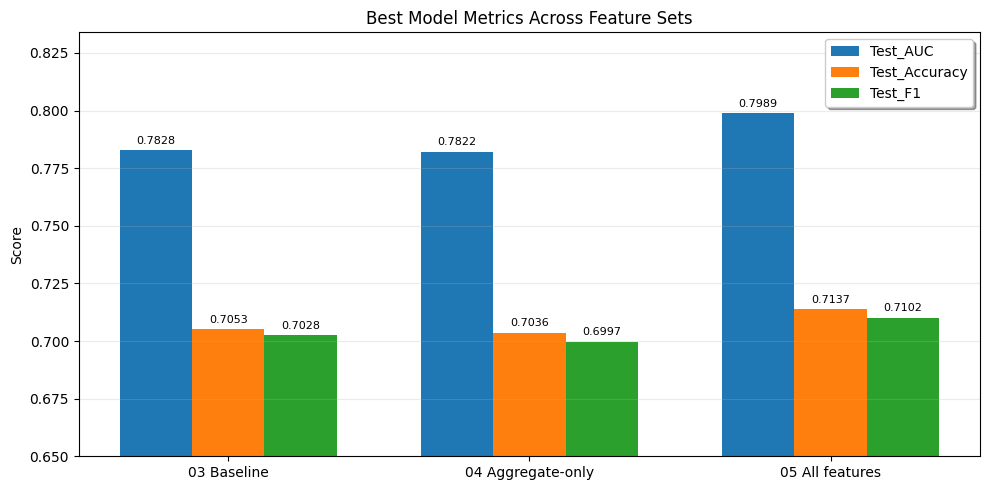

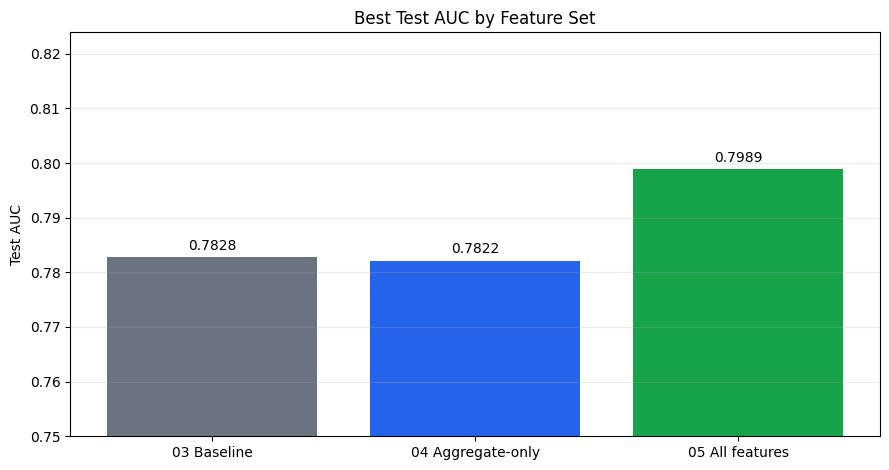

In [14]:
best_summary = overall_summary[
    (overall_summary["Selected_Model_Type"] == "BestModel")
    | (overall_summary["Notebook"] == "03_baseline_model_kaggle")
].copy()

best_summary["Experiment"] = [
    "03 Baseline",
    "04 Aggregate-only",
    "05 All features",
]

best_model_by_feature_set = best_summary[["Experiment", "Model", "Test_AUC", "Test_Accuracy", "Test_F1"]].copy()
best_model_by_feature_set.to_csv(SUMMARY_DIR / "best_model_by_feature_set.csv", index=False)
display(best_model_by_feature_set)

metric_cols = ["Test_AUC", "Test_Accuracy", "Test_F1"]
plot_df = best_summary.melt(
    id_vars=["Experiment", "Model"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(best_summary))
width = 0.24

for i, metric in enumerate(metric_cols):
    values = best_summary[metric].to_numpy()
    bars = ax.bar(x + (i - 1) * width, values, width, label=metric)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(best_summary["Experiment"], rotation=0)
ax.set_ylim(0.65, max(best_summary[metric_cols].max()) + 0.035)
ax.set_ylabel("Score")
ax.set_title("Best Model Metrics Across Feature Sets")
ax.legend(loc="upper right", frameon=True, shadow=True)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(SUMMARY_DIR / "feature_set_metric_comparison.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(best_summary["Experiment"], best_summary["Test_AUC"], color=["#6b7280", "#2563eb", "#16a34a"])
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_ylim(0.75, best_summary["Test_AUC"].max() + 0.025)
ax.set_ylabel("Test AUC")
ax.set_title("Best Test AUC by Feature Set")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(SUMMARY_DIR / "feature_set_auc_comparison.png", dpi=160)
plt.show()

## 5. Improvement Table

,Comparison,From,To,Delta_Test_AUC,Delta_Test_Accuracy,Delta_Test_F1
0,Aggregate-only best vs baseline,03 Baseline,04 Aggregate-only,-0.000648,-0.001605,-0.003032
1,All-features best vs aggregate-only best,04 Aggregate-only,05 All features,0.016758,0.010066,0.010456
2,All-features best vs baseline,03 Baseline,05 All features,0.016110,0.008461,0.007424


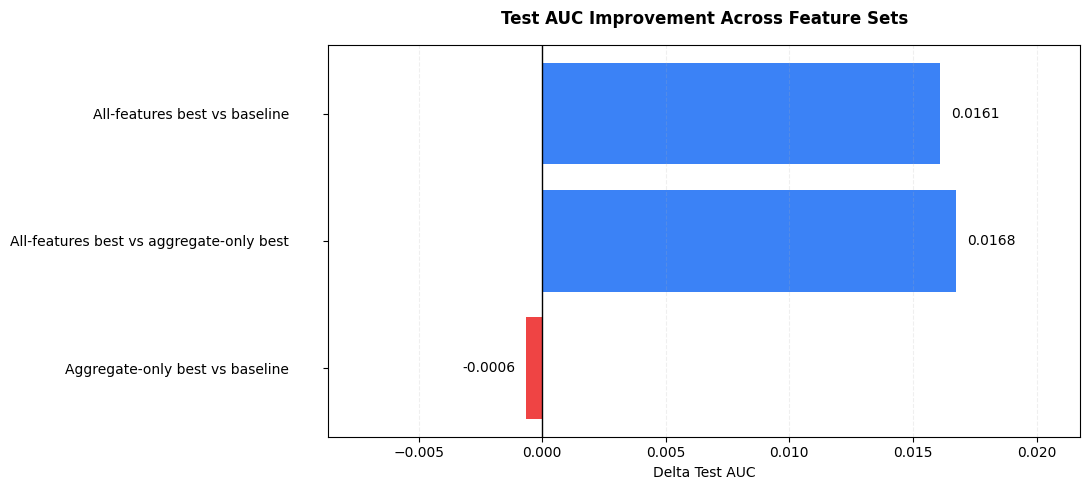

In [15]:
def metric_delta(row_a, row_b, label):
    return {
        "Comparison": label,
        "From": row_a["Experiment"],
        "To": row_b["Experiment"],
        "Delta_Test_AUC": row_b["Test_AUC"] - row_a["Test_AUC"],
        "Delta_Test_Accuracy": row_b["Test_Accuracy"] - row_a["Test_Accuracy"],
        "Delta_Test_F1": row_b["Test_F1"] - row_a["Test_F1"],
    }


baseline_best = best_summary.iloc[0]
aggregate_best = best_summary.iloc[1]
all_features_best = best_summary.iloc[2]

improvement_summary = pd.DataFrame(
    [
        metric_delta(baseline_best, aggregate_best, "Aggregate-only best vs baseline"),
        metric_delta(aggregate_best, all_features_best, "All-features best vs aggregate-only best"),
        metric_delta(baseline_best, all_features_best, "All-features best vs baseline"),
    ]
)
improvement_summary.to_csv(SUMMARY_DIR / "feature_set_improvement.csv", index=False)
display(improvement_summary)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(improvement_summary["Comparison"], improvement_summary["Delta_Test_AUC"], 
              color=['#ef4444' if x < 0 else '#3b82f6' for x in improvement_summary["Delta_Test_AUC"]])

ax.bar_label(bars, fmt="%.4f", padding=8)
ax.axvline(0, color="black", linewidth=1)

ax.tick_params(axis='y', pad=25)
ax.set_xlim(improvement_summary["Delta_Test_AUC"].min() - 0.008, 
            improvement_summary["Delta_Test_AUC"].max() + 0.005)

ax.set_xlabel("Delta Test AUC")
ax.set_title("Test AUC Improvement Across Feature Sets", fontweight='bold', pad=15)
ax.grid(axis="x", alpha=0.2, linestyle='--')

fig.tight_layout()
plt.show()

## 6. Logistic Regression vs Best Model

In [16]:
logreg_vs_best_rows = []
for feature_set, summary_df, best_model_name in [
    ("Aggregate-only", agg_summary, agg_best_model),
    ("All features", all_summary, all_best_model),
]:
    best = summary_df.loc[best_model_name]
    logreg = summary_df.loc["LogisticRegression"]
    logreg_vs_best_rows.append(
        {
            "Feature_Set": feature_set,
            "Best_Model": best_model_name,
            "Best_Test_AUC": best["Test_AUC"],
            "LogReg_Test_AUC": logreg["Test_AUC"],
            "Best_minus_LogReg_Test_AUC": best["Test_AUC"] - logreg["Test_AUC"],
            "Best_Test_Accuracy": best["Test_Accuracy"],
            "LogReg_Test_Accuracy": logreg["Test_Accuracy"],
            "Best_minus_LogReg_Test_Accuracy": best["Test_Accuracy"] - logreg["Test_Accuracy"],
            "Best_Test_F1": best["Test_F1"],
            "LogReg_Test_F1": logreg["Test_F1"],
            "Best_minus_LogReg_Test_F1": best["Test_F1"] - logreg["Test_F1"],
        }
    )

logreg_vs_best = pd.DataFrame(logreg_vs_best_rows)
logreg_vs_best.to_csv(SUMMARY_DIR / "logistic_regression_vs_best_model.csv", index=False)
display(logreg_vs_best)

,Feature_Set,Best_Model,Best_Test_AUC,LogReg_Test_AUC,Best_minus_LogReg_Test_AUC,Best_Test_Accuracy,LogReg_Test_Accuracy,Best_minus_LogReg_Test_Accuracy,Best_Test_F1,LogReg_Test_F1,Best_minus_LogReg_Test_F1
0,Aggregate-only,CatBoost,0.782165,0.781242,0.000923,0.703647,0.703647,0.00000,0.699727,0.701228,-0.001501
1,All features,CatBoost,0.798923,0.797066,0.001857,0.713713,0.717433,-0.00372,0.710182,0.715691,-0.005508


## 7. Feature Importance Summary

In [17]:
def top_features(df, model_name=None, top_n=12):
    data = df.copy()
    if model_name is not None and "model" in data.columns:
        data = data[data["model"] == model_name].copy()
    return data.sort_values("importance", ascending=False).head(top_n)


baseline_top = baseline_importance.sort_values("importance", ascending=False).head(12).copy()
baseline_top["model"] = "LogisticRegression"
baseline_top["feature_group"] = "raw_encoded_features"

agg_logreg_top = top_features(agg_importance, "LogisticRegression", 12)
agg_best_top = top_features(agg_importance, agg_best_model, 12)
all_logreg_top = top_features(all_importance, "LogisticRegression", 12)
all_best_top = top_features(all_importance, all_best_model, 12)

feature_importance_summary = pd.concat(
    [
        baseline_top.assign(Experiment="03 Baseline LogisticRegression"),
        agg_logreg_top.assign(Experiment="04 Aggregate-only LogisticRegression"),
        agg_best_top.assign(Experiment=f"04 Aggregate-only Best ({agg_best_model})"),
        all_logreg_top.assign(Experiment="05 All-features LogisticRegression"),
        all_best_top.assign(Experiment=f"05 All-features Best ({all_best_model})"),
    ],
    ignore_index=True,
    sort=False,
)

feature_importance_summary.to_csv(SUMMARY_DIR / "feature_importance_summary.csv", index=False)
display(feature_importance_summary[["Experiment", "model", "feature", "importance", "direction", "feature_group"]].head(60))

,Experiment,model,feature,importance,direction,feature_group
0,03 Baseline LogisticRegression,LogisticRegression,TotalGold_P8,0.499344,Red-favored,raw_encoded_features
1,03 Baseline LogisticRegression,LogisticRegression,TotalGold_P1,0.458955,Blue-favored,raw_encoded_features
2,03 Baseline LogisticRegression,LogisticRegression,TotalGold_P4,0.407564,Blue-favored,raw_encoded_features
3,03 Baseline LogisticRegression,LogisticRegression,TotalGold_P6,0.351357,Red-favored,raw_encoded_features
4,03 Baseline LogisticRegression,LogisticRegression,TotalGold_P3,0.339859,Blue-favored,raw_encoded_features
5,03 Baseline LogisticRegression,LogisticRegression,TotalGold_P9,0.314973,Red-favored,raw_encoded_features
6,03 Baseline LogisticRegression,LogisticRegression,MinionsKilled_P7,0.241514,Red-favored,raw_encoded_features
7,03 Baseline LogisticRegression,LogisticRegression,TotalGold_P7,0.225906,Red-favored,raw_encoded_features
8,03 Baseline LogisticRegression,LogisticRegression,TotalGold_P5,0.221202,Blue-favored,raw_encoded_features
9,03 Baseline LogisticRegression,LogisticRegression,TotalGold_P10,0.220584,Red-favored,raw_encoded_features


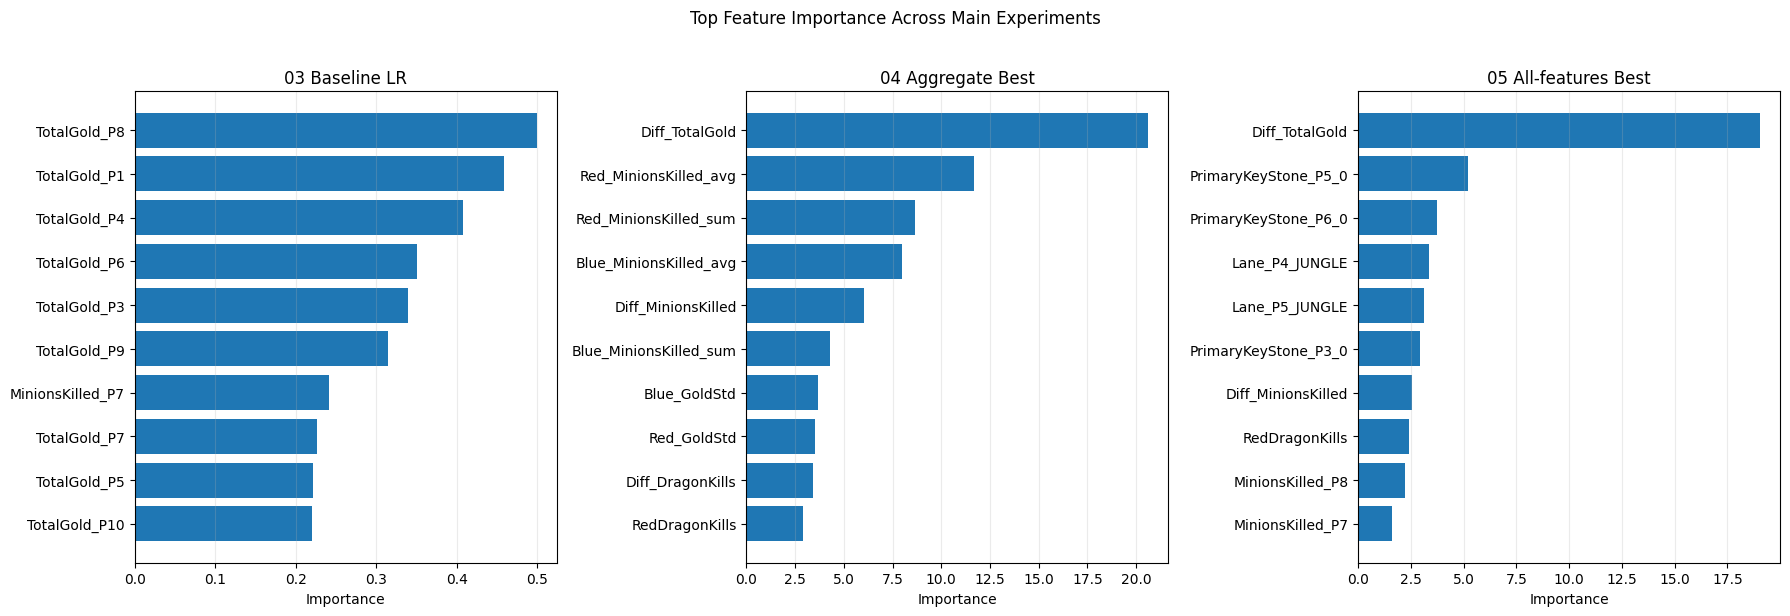

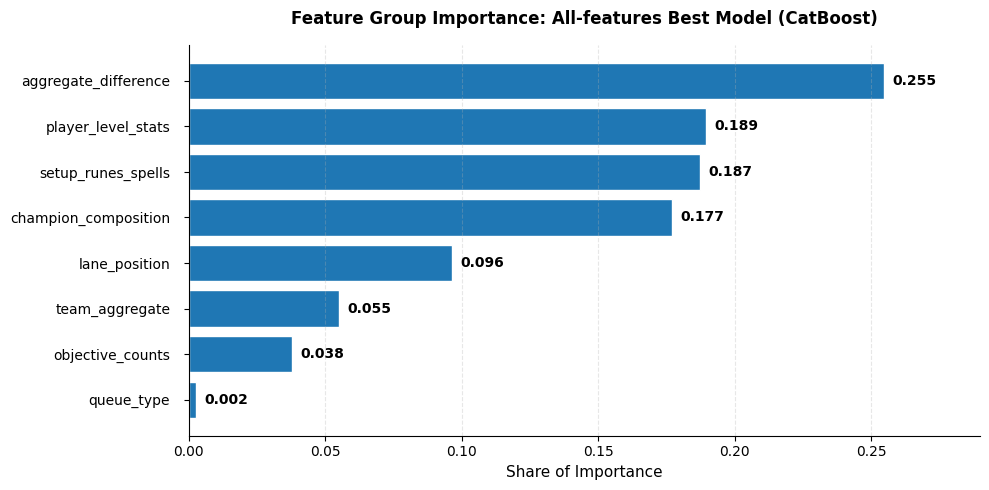

In [18]:
plot_sets = [
    ("03 Baseline LR", baseline_top, "feature"),
    ("04 Aggregate Best", agg_best_top, "feature"),
    ("05 All-features Best", all_best_top, "feature"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (title, data, feature_col) in zip(axes, plot_sets):
    plot_data = data.sort_values("importance", ascending=True).tail(10)
    ax.barh(plot_data[feature_col], plot_data["importance"])
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.25)

fig.suptitle("Top Feature Importance Across Main Experiments", y=1.02)
fig.tight_layout()
fig.savefig(SUMMARY_DIR / "feature_importance_side_by_side.png", dpi=160, bbox_inches="tight")
plt.show()

group_best = all_group_importance[all_group_importance["model"] == all_best_model].copy()
group_best = group_best.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(group_best["feature_group"], group_best["share"], edgecolor='white')
ax.bar_label(bars, fmt="%.3f", padding=6, fontweight='bold')

ax.set_xlim(0, group_best["share"].max() + 0.035)
ax.set_xlabel("Share of Importance", fontsize=11)
ax.set_title(f"Feature Group Importance: All-features Best Model ({all_best_model})", fontweight='bold', pad=15)

ax.grid(axis="x", alpha=0.3, linestyle='--')
ax.tick_params(axis='y', labelsize=10, pad=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Output Files

In [19]:
created_files = sorted(SUMMARY_DIR.glob("*"))
for path in created_files:
    print(path)

outputs\final_summary\all_features_group_importance_summary.png
outputs\final_summary\all_model_comparison.csv
outputs\final_summary\best_model_by_feature_set.csv
outputs\final_summary\feature_importance_side_by_side.png
outputs\final_summary\feature_importance_summary.csv
outputs\final_summary\feature_set_auc_comparison.png
outputs\final_summary\feature_set_auc_comparison.svg
outputs\final_summary\feature_set_auc_improvement.png
outputs\final_summary\feature_set_auc_improvement.svg
outputs\final_summary\feature_set_improvement.csv
outputs\final_summary\feature_set_metric_comparison.png
outputs\final_summary\logistic_regression_vs_best_model.csv
outputs\final_summary\numeric_conclusion.txt
outputs\final_summary\overall_model_summary.csv


## 9. Numeric Conclusion

In [20]:
best_overall = best_summary.sort_values("Test_AUC", ascending=False).iloc[0]
baseline_auc = baseline_best["Test_AUC"]
aggregate_auc = aggregate_best["Test_AUC"]
all_auc = all_features_best["Test_AUC"]

conclusion_lines = [
    f"Best overall experiment: {best_overall['Experiment']} using {best_overall['Model']} with Test AUC = {best_overall['Test_AUC']:.4f}.",
    f"Baseline Test AUC = {baseline_auc:.4f}.",
    f"Aggregate-only best Test AUC = {aggregate_auc:.4f}, delta vs baseline = {aggregate_auc - baseline_auc:+.4f}.",
    f"All-features best Test AUC = {all_auc:.4f}, delta vs aggregate-only = {all_auc - aggregate_auc:+.4f}.",
    f"All-features best delta vs baseline = {all_auc - baseline_auc:+.4f}.",
    f"In aggregate-only, best model minus Logistic Regression Test AUC = {logreg_vs_best.loc[0, 'Best_minus_LogReg_Test_AUC']:+.4f}.",
    f"In all-features, best model minus Logistic Regression Test AUC = {logreg_vs_best.loc[1, 'Best_minus_LogReg_Test_AUC']:+.4f}.",
]

conclusion_text = "\n".join(conclusion_lines)
(SUMMARY_DIR / "numeric_conclusion.txt").write_text(conclusion_text, encoding="utf-8")
print(conclusion_text)

Best overall experiment: 05 All features using CatBoost with Test AUC = 0.7989.
Baseline Test AUC = 0.7828.
Aggregate-only best Test AUC = 0.7822, delta vs baseline = -0.0006.
All-features best Test AUC = 0.7989, delta vs aggregate-only = +0.0168.
All-features best delta vs baseline = +0.0161.
In aggregate-only, best model minus Logistic Regression Test AUC = +0.0009.
In all-features, best model minus Logistic Regression Test AUC = +0.0019.
